<h1>NAO Teleconnections - Wind - ERA5 vs SEAS5</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import gc
import collections
import numpy as np
from io import BytesIO
from PIL import Image
import scipy
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.regridder import Regrid
from src.util import oni, timeutil, stats

import warnings
warnings.filterwarnings('ignore')

<h3>User Configurables</h3>

In [3]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/mslp/'

In [4]:
era5_var = 'mean_sea_level_pressure'
seas5_var = 'msl'

In [5]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonth = 11  # Only get this init within the time_range

# Form Composites around these leads.
# You could also specify a single lead, like, leads=1
leads = 3 #(0, 1, 2, 3)

In [6]:
# For NAO, there are 2 reference locations:
region_1 = {'latmin': 65.0, 'lonmin': 331.2}
region_2 = {'latmin': 37.7, 'lonmin': 334.3}

In [7]:
# Transform leads into a tuple used for slicing.
if isinstance(leads, int):
    leads = tuple([leads])

<h3>First step is to calculate NAO Index</h3>

<h5>Get data readers</h5>

In [8]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [9]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [10]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [11]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [12]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                                      lat=region_1['latmin'], lon=region_1['lonmin']).load()

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                                      lat=region_2['latmin'], lon=region_2['lonmin']).load()

In [13]:
seas5_ds_1 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_1['latmin'],
                                        lon=region_1['lonmin'],
                                        initmonths=initmonth,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

seas5_ds_2 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_2['latmin'],
                                        lon=region_2['lonmin'],
                                        initmonths=initmonth,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

Taking Ensemble Average
Taking Ensemble Average


In [14]:
# Ensure that temporal domains perfectly match.
era5_ds_1 = timeutil.match_time_to_leads(verif_ds=era5_ds_1,
                                         ufs_ds=seas5_ds_1)

era5_ds_2 = timeutil.match_time_to_leads(verif_ds=era5_ds_2,
                                         ufs_ds=seas5_ds_2)

<h5>Calculate climatologies for each dataset (this may take a couple minutes)</h5>

In [15]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

In [16]:
seas5_stats_1 = stats.calc_climatology_anomaly(seas5_ds_1, area_mean=False, use_member_climatology=False)
seas5_stats_2 = stats.calc_climatology_anomaly(seas5_ds_2, area_mean=False, use_member_climatology=False)

<h5>Normalize the data. z = (X - mu) / sigma</h5>

In [17]:
# Normalize SEAS5 datasets
seas5_da_1 = stats.normalize(da=seas5_ds_1[seas5_var], stats=seas5_stats_1)
seas5_da_2 = stats.normalize(da=seas5_ds_2[seas5_var], stats=seas5_stats_2)

In [18]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h3>Calculate NAO Index</h3>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [19]:
era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])

In [20]:
seas5_ds_nao = (seas5_da_2 - seas5_da_1).to_dataset()
era5_ds_nao = (era5_da_2 - era5_da_1).to_dataset()

<h1>Now that NAO Index is calculated, we can form Wind composites</h1>

<h5>First, classify which forecast leads (UFS) or times (Verif) are in positive or negative phase</h5>

In [21]:
# This is when ERA5 NAO is positive or negative
era5_positive_exclude_initleads = []
era5_negative_exclude_initleads = []

for this_time in era5_ds_nao.time.values:
    
    # Get calendar month number
    this_month_number = pd.to_datetime(this_time).month
    
    # Calculate lead. two cases for handling calendar months
    if this_month_number >= initmonth:
        this_lead = this_month_number - initmonth
    else:
        this_lead = this_month_number + (12-initmonth)
    
    # Get the corresponding init time
    this_init = timeutil.time_offset(freq_unit='MS',
                                     init=this_time,
                                     lead=this_lead,
                                     step=np.timedelta64(30, 'D'),
                                     direction='backward')
    # This NAO value
    this_nao_value = era5_ds_nao[era5_var].sel(time=this_time).values.item()
    
    # Is this NAO value non-positive or non-negative?
    if this_nao_value >= 0:
        era5_negative_exclude_initleads.append((this_init, this_lead))

    elif this_nao_value <= 0:
        era5_positive_exclude_initleads.append((this_init, this_lead))

In [22]:
# This is when UFS NAO is positive or negative
seas5_positive_exclude_initleads = []
seas5_negative_exclude_initleads = []

for this_init in seas5_ds_nao.init.values:    
    for this_lead in seas5_ds_nao.lead.values:        
        # This NAO value
        this_nao_value = seas5_ds_nao[seas5_var].sel(init=this_init, lead=this_lead).values.item()
        
        # Is this NAO value non-positive or non-negative?
        if this_nao_value >= 0:
            seas5_negative_exclude_initleads.append((this_init, this_lead))
            
        elif this_nao_value <= 0:
            seas5_positive_exclude_initleads.append((this_init, this_lead))

<h3>Compute Wind composite</h3>

In [23]:
# seas5st data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/uv/'

In [24]:
seas5_var = ['u', 'v']
era5_var = ['u_component_of_wind', 'v_component_of_wind']
lev = 200

In [25]:
# 1 indicator shall refer to VERIF data
data_reader1 = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [26]:
# 2 indicator shall refer to SEAS5 data
# Our Regridder requires 1 UFS-type data reader.
# What we will do is instantiate a UFS data reader,
# but then supplant its data with the SEAS5 dataset.
data_reader2 = dr.getDataReader(datasource='UFS',                  
                                experiment = 'baseline',
                                # filename=f'experiments/phase_1/{ufs_experiment}/atm_monthly.zarr',
                                model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr


In [27]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [28]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [29]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                 'number': 'member',
                                 'pressure_level': 'lev'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member',
                            'pressure_level': 'lev'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
data_reader2.update(ds=seas5_ds) 

Dataset updated.


In [30]:
ds1 = data_reader1.retrieve(var=era5_var, lev=lev)

In [31]:
ds2 = data_reader2.retrieve(var=seas5_var,
                            time=time_range,
                            lev=lev,
                            initmonths=initmonth,
                            lead=(min(leads), max(leads)),
                            member=(0, 24), # We know seas5 hindcast has members 0-24
                            ens_avg=True)

Taking Ensemble Average


In [32]:
# Ensure that temporal domains perfectly match.
ds1 = timeutil.match_time_to_leads(verif_ds=ds1,
                                   ufs_ds=ds2)

In [33]:
# Update datareaders with subsetted and scaled data.
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h5>Instantiate Regridder</h5>

In [34]:
regridder = Regrid.Regrid(data_reader1=data_reader1,                                                              
                          data_reader2=data_reader2,                                                            
                          method='linear')


Regrid Object initialized.

___Resample Instructions___
data_reader1 must be temporally resampled before spatially regridding.
Resample these data by running <RegridObj>.resample(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for resample, run <RegridObj>.resample_vars()

___Regrid Instructions___
Initialized the Regridder with method 'linear'
Input grid shape data_reader1 (ERA5_DataReader): lat 256, lon 512
Output grid shape data_reader2 (UFS_DataReader): lat 180, lon 360
Regrid these data by running <RegridObj>.regrid(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for regrid, run <RegridObj>.regrid_vars()

___Align Instructions___
data_reader1 can have its time coordinates converted to init+lead.
Lead resolution of the UFS dataset interpreted as monthly intervals.
Align these data by running <RegridObj>.align() (You may need to resample and/or regrid first.)



In [35]:
# Get vars to resample and regrid
vars_to_resample = era5_var
vars_to_regrid = list(globals()[f'data_reader{regridder.highres_grid}'].dataset().keys())
print(f'will resample {vars_to_resample}')
print(f'will regrid {vars_to_regrid}')

will resample ['u_component_of_wind', 'v_component_of_wind']
will regrid ['u_component_of_wind', 'v_component_of_wind']


In [36]:
# RESAMPLE.  (Give this a few minutes to complete.)
regridder.resample(var=vars_to_resample)

Resampling data_reader1 data to 'MS' using mean aggregation.
Resampling from 1994-11-01T00 to 2021-12-31T18
Number of cores available: 6
Finished multiprocessing.  Concatenating results.
Resample completed in 12.2 minutes.
Resample results stored in <RegridObj>.resampled


In [37]:
# REGRID.
regridder.regrid(var=vars_to_regrid)

Regridding data_reader1 grid (ERA5_DataReader) onto data_reader2 grid (UFS_DataReader)
Running spherical harmonics on u_component_of_wind and v_component_of_wind
Completed sperical harmonics in 0.64 minutes.
Regrid results stored in <RegridObj>.regridded


In [38]:
# ALIGN.
regridder.align()

Aligning time coordinate to init+lead coordinates.
MODEL_LEADS: [3]
Time dimensions aligned:  matched 27 timesteps
Align results stored in <RegridObj>.aligned


In [39]:
# Datasets have been pre-processed.
# Need some logic here to extract the results.

# For these notebooks, we know that Verif data are aligned:
ds1 = regridder.aligned.dataset()

# SEAS5 data could be in the regridded slot or not, depending on the experiment we're working with.
if regridder.highres_grid == 2:
    ds2 = regridder.regridded.dataset()
else:
    ds2 = data_reader2.dataset()


In [40]:
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h3>Ready for ONI calculations!</h3>

In [41]:
ds1_positive_statistics = stats.calc_composite_layers(data_reader=data_reader1,
                                                      var=era5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=era5_positive_exclude_initleads)

ds1_negative_statistics = stats.calc_composite_layers(data_reader=data_reader1,
                                                      var=era5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=era5_negative_exclude_initleads)

ds2_positive_statistics = stats.calc_composite_layers(data_reader=data_reader2,
                                                      var=seas5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=seas5_positive_exclude_initleads)

ds2_negative_statistics = stats.calc_composite_layers(data_reader=data_reader2,
                                                      var=seas5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=seas5_negative_exclude_initleads)

Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.


<h3>Run t-tests</h3>

In [42]:
ds1_positive_statistics = ds1_positive_statistics.squeeze(dim=['lev'])
ds1_negative_statistics = ds1_negative_statistics.squeeze(dim=['lev'])
ds2_positive_statistics = ds2_positive_statistics.squeeze(dim=['lev'])
ds2_negative_statistics = ds2_negative_statistics.squeeze(dim=['lev'])

In [43]:
# Get position of init and lead axes
dims = list(ds1_positive_statistics['anomaly'].dims) 
ttest_axes = []
if 'init' in dims:
    ttest_axes.append(dims.index("init"))
if 'lead' in dims:
    ttest_axes.append(dims.index("lead"))

In [44]:
# POSITIVE
anomaly_tstatistic_positive, anomaly_pvalue_positive =\
    scipy.stats.ttest_ind(a=ds1_positive_statistics['anomaly'].values,
                          b=ds2_positive_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

# NEGATIVE
anomaly_tstatistic_negative, anomaly_pvalue_negative =\
    scipy.stats.ttest_ind(a=ds1_negative_statistics['anomaly'].values,
                          b=ds2_negative_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

<h5>Package statistics</h5>

In [45]:
p_values = xr.Dataset(
    data_vars={
        'anomaly_pvalue_positive': (('lat', 'lon'), anomaly_pvalue_positive),
        'anomaly_pvalue_negative': (('lat', 'lon'), anomaly_pvalue_negative)
        
    },
    coords={
        'lat': data_reader1.dataset().lat.values,
        'lon': data_reader1.dataset().lon.values
    }
)

<h3>Anomaly</h3>

In [46]:
# This is the DataArray for the Composite
ds1_positive_composite = ds1_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds1_negative_composite = ds1_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

ds2_positive_composite = ds2_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds2_negative_composite = ds2_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

# Calculate the difference in anomalies
positive_ds2_minus_ds1 = ds2_positive_composite - ds1_positive_composite
negative_ds2_minus_ds1 = ds2_negative_composite - ds1_negative_composite

# Calculate Correlations
positive_corr = xr.corr(ds1_positive_composite, ds2_positive_composite).values.item()
negative_corr = xr.corr(ds1_negative_composite, ds2_negative_composite).values.item()

<h5>Make labels for the plots</h5>

In [47]:
def count_phases(da):
    '''Ad hoc function:  Count the number of init leads with defined data.'''
    n_phases = 0
    # Loop over init-leads
    for this_init in da.init.values:
        for this_lead in da.lead.values:

            # Check if all nan
            if not np.isnan(da.sel(init=this_init, lead=this_lead).values).all():
                n_phases += 1

    return n_phases

In [48]:
n_era5_positive_phases = f"# Positive Phases: {count_phases(ds1_positive_statistics['anomaly'])}"
n_era5_negative_phases = f"# Negative Phases: {count_phases(ds1_negative_statistics['anomaly'])}"

n_seas5_positive_phases = f"# Positive Phases: {count_phases(ds2_positive_statistics['anomaly'])}"
n_seas5_negative_phases = f"# Negative Phases: {count_phases(ds2_negative_statistics['anomaly'])}"

# Label for init and leads
initlead_label = f"init {initmonth}\nlead {' '.join(filter(str.isdigit, str(leads)))}"

# Label for correlation
positive_corr_label = f'corr: {positive_corr:.2f}'
negative_corr_label = f'corr: {negative_corr:.2f}'

<h3>Generate figures</h3>

In [49]:
%%capture captured_output

# Instantiate buffers
buffer1 = BytesIO()
buffer2 = BytesIO()
buffer3 = BytesIO()
buffer4 = BytesIO()
buffer5 = BytesIO()
buffer6 = BytesIO()

# Make 6 plots
plot_kwargs = {'cmap_label': 'm s-1',
               'cmap': 'custom_btr',
               'topleft_label': initlead_label,
               'dpi': 200}

plot1 = stats.plot_composite(da = ds1_positive_composite,
                             title=f'{data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Positive NAO Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_era5_positive_phases, **plot_kwargs)

plt.savefig(buffer1, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot2 = stats.plot_composite(da = ds1_negative_composite,
                             title=f'{data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Negative NAO Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_era5_negative_phases, **plot_kwargs)

plt.savefig(buffer2, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot3 = stats.plot_composite(da = ds2_positive_composite,
                             title=f'SEAS5 Zonal Wind Anomaly lev={lev} (Positive NAO Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_seas5_positive_phases, **plot_kwargs)

plt.savefig(buffer3, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot4 = stats.plot_composite(da = ds2_negative_composite,
                             title=f'SEAS5 Zonal Wind Anomaly lev={lev} (Negative NAO Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_seas5_negative_phases, **plot_kwargs)

plt.savefig(buffer4, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot5 = stats.plot_composite(da = positive_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_positive'],
                             shading_threshold = 0.05,
                             title=f'SEAS5 minus {data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Positive NAO Phase)',
                             vmin=-4, vmax=4,
                             bottomright_label=positive_corr_label,
                             **plot_kwargs)

plt.savefig(buffer5, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot6 = stats.plot_composite(da = negative_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_negative'],
                             shading_threshold = 0.05,
                             title=f'SEAS5 minus {data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Negative NAO Phase)',
                             vmin=-4, vmax=4,
                             bottomright_label=negative_corr_label,
                             **plot_kwargs)

plt.savefig(buffer6, format='png', bbox_inches='tight')

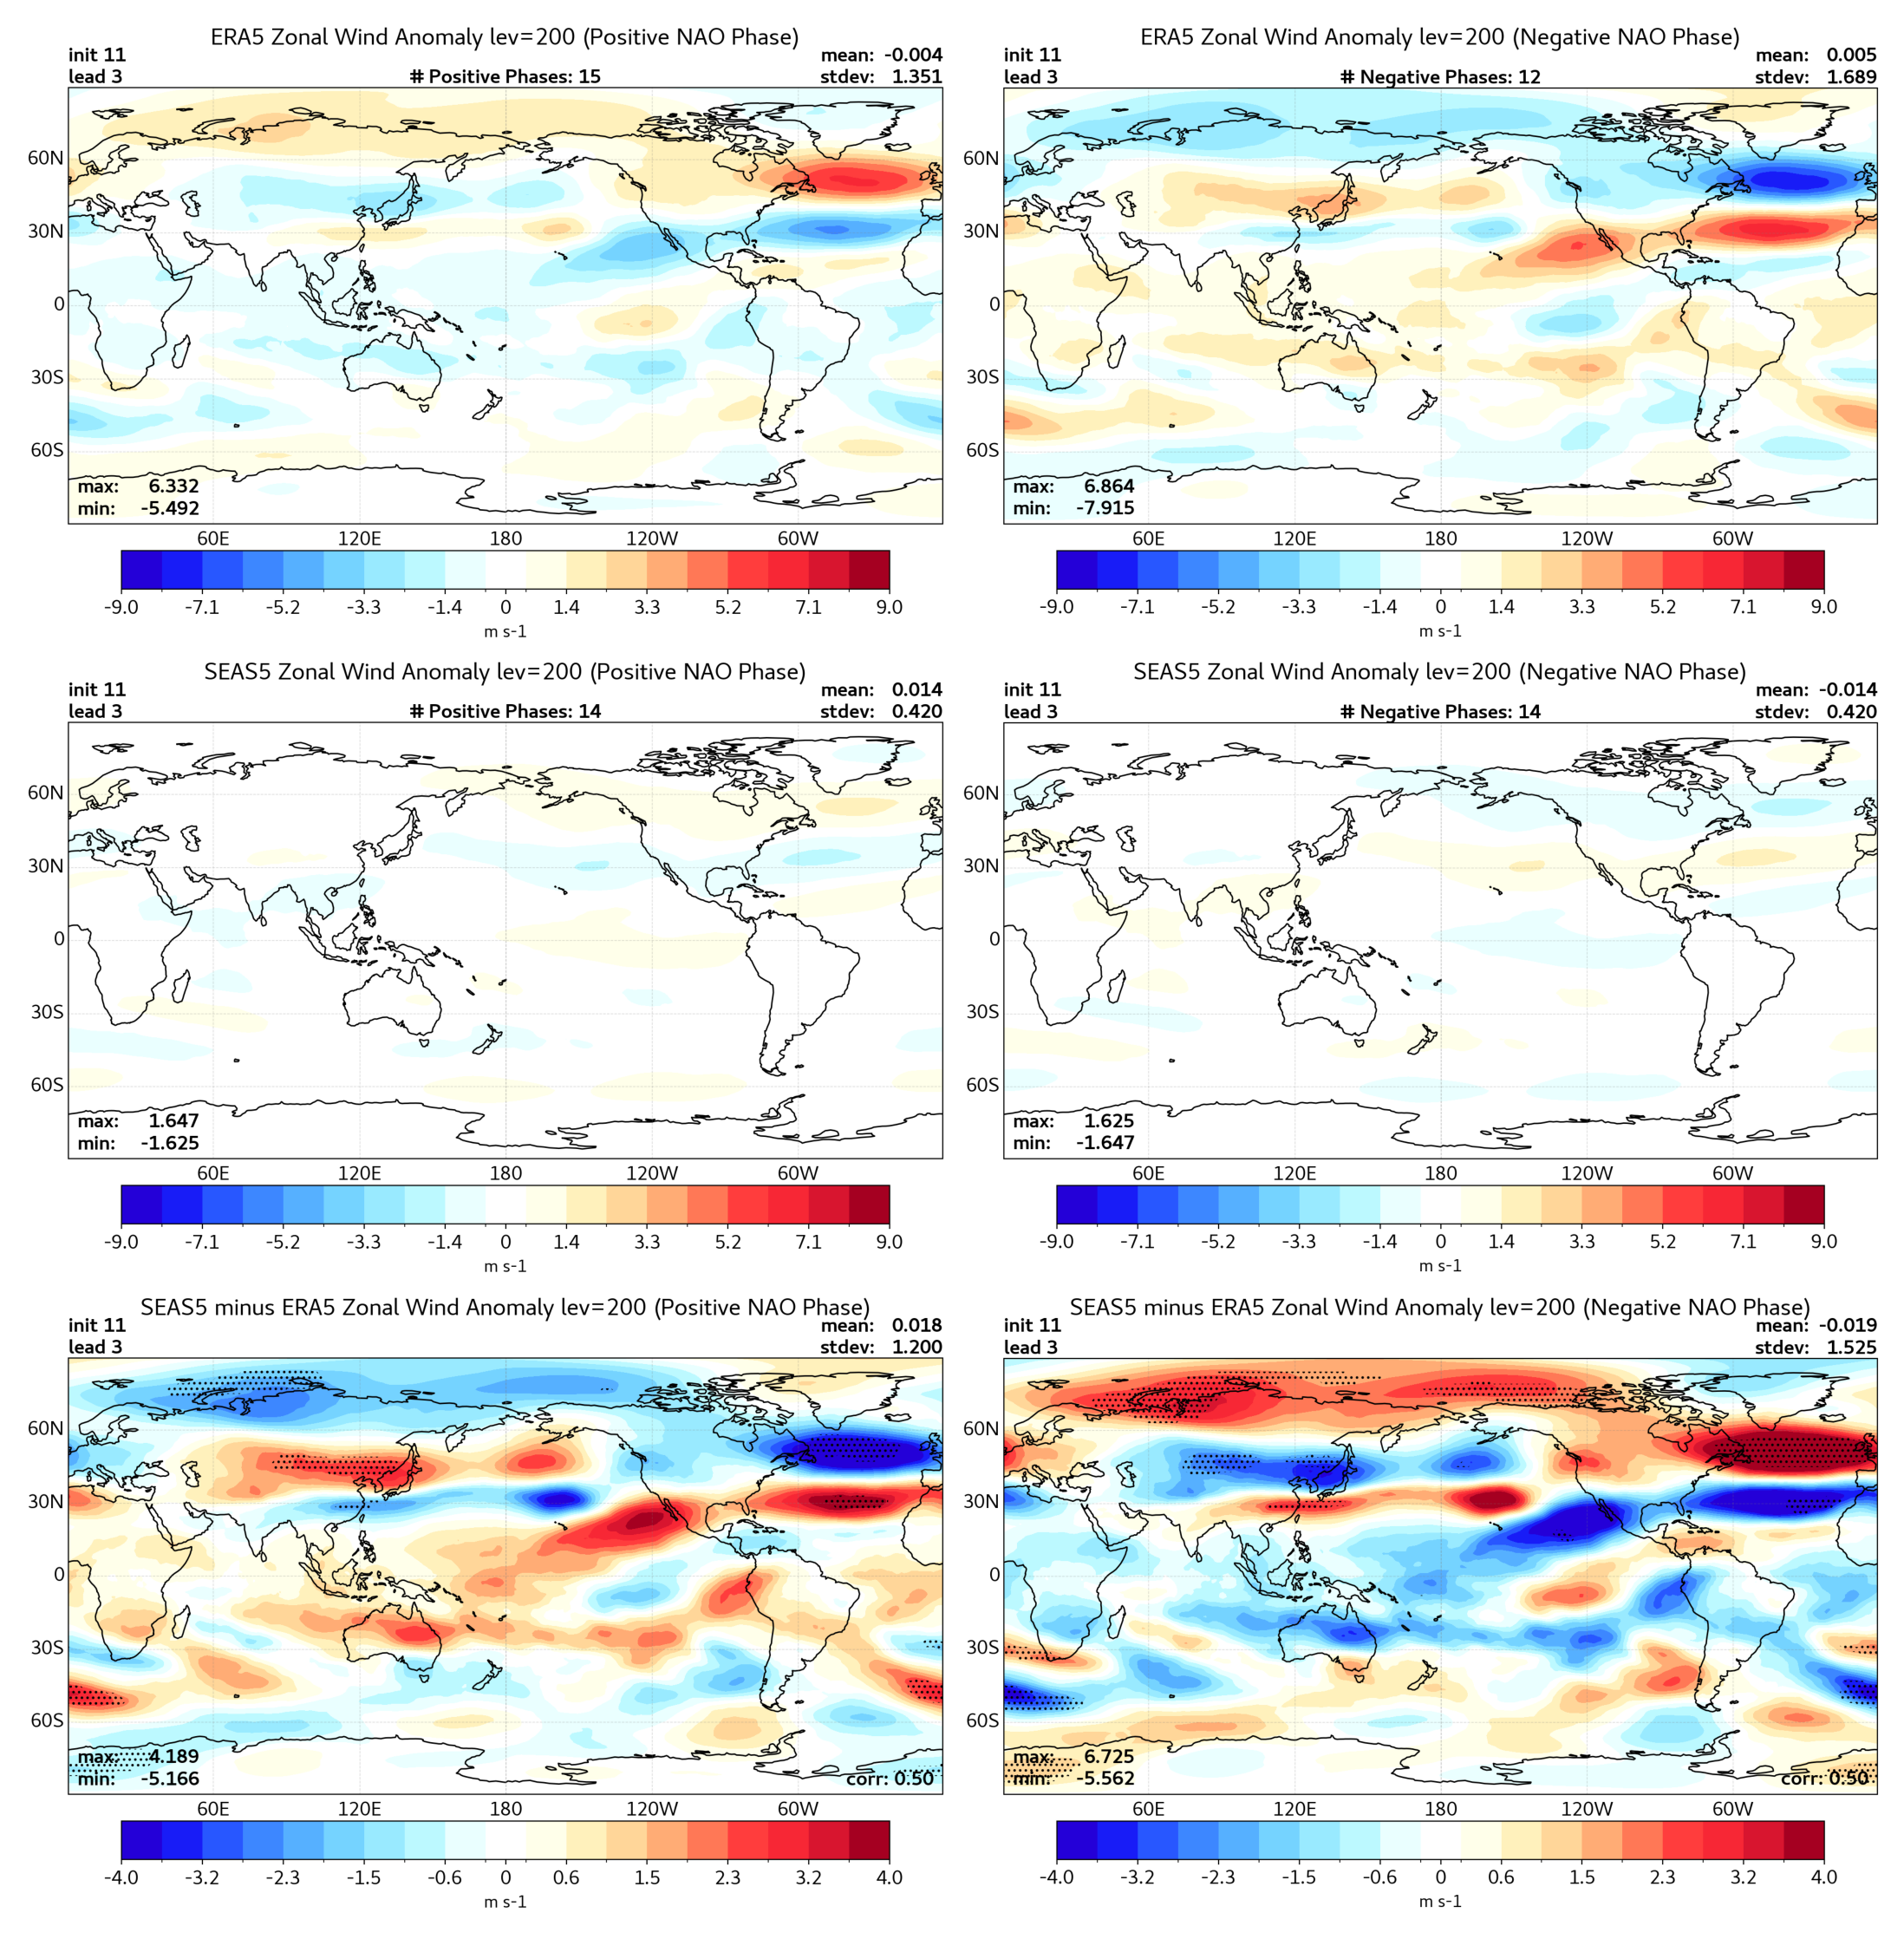

In [50]:
# Convert to images
image1 = Image.open(buffer1)
image2 = Image.open(buffer2)
image3 = Image.open(buffer3)
image4 = Image.open(buffer4)
image5 = Image.open(buffer5)
image6 = Image.open(buffer6)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 11), dpi=200)

axs[0, 0].imshow(image1)
axs[0, 0].axis('off')

axs[0, 1].imshow(image2)
axs[0, 1].axis('off')

axs[1, 0].imshow(image3)
axs[1, 0].axis('off')

axs[1, 1].imshow(image4)
axs[1, 1].axis('off')

axs[2, 0].imshow(image5)
axs[2, 0].axis('off')

axs[2, 1].imshow(image6)
axs[2, 1].axis('off')

plt.gca().set_frame_on(False)
plt.tight_layout(pad=.05)
plt.show()